<a href="https://colab.research.google.com/github/RientArlCroud/Challenge-4-telecom-X-2-an-lisis-de-datos/blob/main/Challenge_4_an%C3%A1lisis_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 3 Análisis de datos, empresa de telecomunicaciones Telecom X

proceso de modelado para identificar posibles cancelaciones del servicio.


In [1]:
import pandas as pd

Lectura de datos

In [2]:
df = pd.read_csv('/content/telecom.csv')

In [3]:
df

,customer_id,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,...,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total,cuentas_diarias,tenure_group,charges_monthly_group
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667,"(6, 12]","(54, 66]"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667,"(6, 12]","(54, 66]"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333,"(0, 6]","(66, 78]"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667,"(12, 24]","(90, 102]"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667,"(0, 6]","(78, 90]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,One year,No,Mailed check,55.15,742.90,1.838333,"(12, 24]","(54, 66]"
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667,"(12, 24]","(78, 90]"
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667,"(0, 6]","(42, 54]"
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667,"(48, 72]","(66, 78]"


Retiro de columnas innecesarias

In [4]:
df.drop(columns=['customer_id','cuentas_diarias', 'tenure_group', 'charges_monthly_group'], axis=1, inplace=True)

In [5]:
df

,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7028,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7029,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


Selección de variables explicativas y variable dependiente (objetivo)

In [6]:
X = df.drop(columns=['churn'], axis=1)
y = df['churn']

In [7]:
X

,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7028,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7029,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [8]:
y

,churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7027,No
7028,Yes
7029,No
7030,No


Proceso de encoding para las variables explicativas y la variable objetivo

In [9]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [10]:
columnas = X.columns
columnas

Index(['customer_gender', 'customer_senior_citizen', 'customer_partner',
       'customer_dependents', 'customer_tenure', 'phone_phone_service',
       'phone_multiple_lines', 'internet_internet_service',
       'internet_online_security', 'internet_online_backup',
       'internet_device_protection', 'internet_tech_support',
       'internet_streaming_tv', 'internet_streaming_movies',
       'account_contract', 'account_paperless_billing',
       'account_payment_method', 'account_charges_monthly',
       'account_charges_total'],
      dtype='object')

In [11]:
one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), ['customer_gender', 'customer_partner', 'customer_dependents',
                                       'phone_phone_service', 'phone_multiple_lines', 'internet_internet_service',
                                       'internet_online_security', 'internet_online_backup', 'internet_device_protection',
                                       'internet_tech_support', 'internet_streaming_tv', 'internet_streaming_movies', 'account_contract',
                                       'account_paperless_billing', 'account_payment_method']),
    remainder = 'passthrough',
    sparse_threshold = 0,
    verbose_feature_names_out = True
)

In [12]:
X = one_hot.fit_transform(X)

In [13]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__customer_gender_Male',
       'onehotencoder__customer_partner_Yes',
       'onehotencoder__customer_dependents_Yes',
       'onehotencoder__phone_phone_service_Yes',
       'onehotencoder__phone_multiple_lines_No',
       'onehotencoder__phone_multiple_lines_No phone service',
       'onehotencoder__phone_multiple_lines_Yes',
       'onehotencoder__internet_internet_service_DSL',
       'onehotencoder__internet_internet_service_Fiber optic',
       'onehotencoder__internet_internet_service_No',
       'onehotencoder__internet_online_security_No',
       'onehotencoder__internet_online_security_No internet service',
       'onehotencoder__internet_online_security_Yes',
       'onehotencoder__internet_online_backup_No',
       'onehotencoder__internet_online_backup_No internet service',
       'onehotencoder__internet_online_backup_Yes',
       'onehotencoder__internet_device_protection_No',
       'onehotencoder__internet_device_protection_No internet service',
 

In [14]:
X

array([[0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 9.00000e+00,
        6.56000e+01, 5.93300e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 9.00000e+00,
        5.99000e+01, 5.42400e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 4.00000e+00,
        7.39000e+01, 2.80850e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 2.00000e+00,
        5.03000e+01, 9.27500e+01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00, ..., 6.70000e+01,
        6.78500e+01, 4.62765e+03],
       [1.00000e+00, 1.00000e+00, 1.00000e+00, ..., 6.30000e+01,
        5.90000e+01, 3.70760e+03]])

In [61]:
X_DF = pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

In [62]:
X_DF

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,...,onehotencoder__account_contract_Two year,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85
3,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90
7028,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70
7029,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75
7030,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
label_encoder = LabelEncoder()

In [18]:
y = label_encoder.fit_transform(y)

In [19]:
y

array([0, 0, 1, ..., 0, 0, 0])

Observando si existe desbalance en la variable objetivo

In [20]:
df['churn'].value_counts()

,count
churn,
No,5163
Yes,1869


In [21]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
No,0.734215
Yes,0.265785


Posible balanceo de datos

In [22]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

In [23]:
oversampling = SMOTE()
undersampling = NearMiss()

In [24]:
X_balanceada_OS, y_balanceada_OS = oversampling.fit_resample(X, y)

In [25]:
pd.Series(y_balanceada_OS).value_counts()

,count
0,5163
1,5163


In [26]:
X_balanceada_US, y_balanceada_US = undersampling.fit_resample(X, y)

In [27]:
pd.Series(y_balanceada_US).value_counts()

,count
0,1869
1,1869


In [28]:
import matplotlib.pyplot as plt

(array([2709., 1228.,  671.,  508.,  454.,  412.,  395.,  310.,  223.,
         122.]),
 array([  18.8,  885.4, 1752. , 2618.6, 3485.2, 4351.8, 5218.4, 6085. ,
        6951.6, 7818.2, 8684.8]),
 <BarContainer object of 10 artists>)

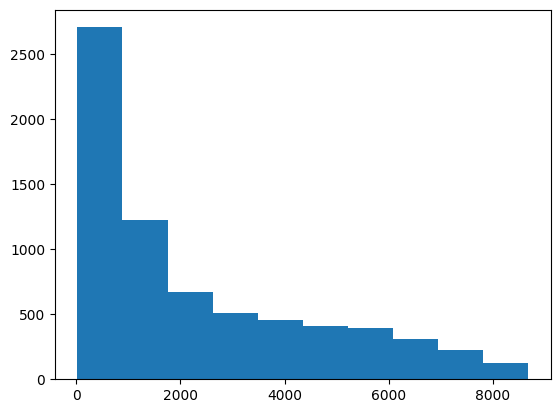

In [29]:
plt.hist(df['account_charges_total'])

In [30]:
df_final = pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas))
df_final['Churn'] = y
df_final

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,...,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total,Churn
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30,0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40,0
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85,1
3,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85,1
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90,0
7028,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70,1
7029,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75,0
7030,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65,0


Análisis de correlación

In [31]:
df_final.corr()

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,...,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total,Churn
onehotencoder__customer_gender_Male,1.000000,-0.001379,0.010349,-0.007515,0.004335,0.007515,-0.008883,0.007584,-0.011189,0.004745,...,-0.011902,-0.015973,0.001632,0.000844,0.013199,-0.001819,0.005285,-0.013779,0.000048,-0.008545
onehotencoder__customer_partner_Yes,-0.001379,1.000000,0.452269,0.018397,-0.130028,-0.018397,0.142561,-0.001043,0.001235,-0.000286,...,-0.013957,0.111406,0.082327,-0.083207,-0.096948,0.016957,0.381912,0.097825,0.319072,-0.149982
onehotencoder__customer_dependents_Yes,0.010349,0.452269,1.000000,-0.001078,0.023388,0.001078,-0.024307,0.051593,-0.164101,0.138383,...,-0.110131,0.052369,0.061134,-0.149274,0.056448,-0.210550,0.163386,-0.112343,0.064653,-0.163128
onehotencoder__phone_phone_service_Yes,-0.007515,0.018397,-0.001078,1.000000,0.315218,-1.000000,0.279530,-0.452255,0.290183,0.171817,...,0.016696,0.008271,-0.006916,0.002747,-0.004463,0.008392,0.007877,0.248033,0.113008,0.011691
onehotencoder__phone_multiple_lines_No,0.004335,-0.130028,0.023388,0.315218,1.000000,-0.315218,-0.823076,-0.069515,-0.190531,0.309984,...,-0.151974,-0.069663,-0.063712,-0.080990,0.222395,-0.136377,-0.323891,-0.338514,-0.396765,-0.032654
onehotencoder__phone_multiple_lines_No phone service,0.007515,-0.018397,0.001078,-1.000000,-0.315218,1.000000,-0.279530,0.452255,-0.290183,-0.171817,...,-0.016696,-0.008271,0.006916,-0.002747,0.004463,-0.008392,-0.007877,-0.248033,-0.113008,-0.011691
onehotencoder__phone_multiple_lines_Yes,-0.008883,0.142561,-0.024307,0.279530,-0.823076,-0.279530,1.000000,-0.200318,0.366420,-0.210794,...,0.163746,0.075429,0.060319,0.083583,-0.227672,0.142996,0.332399,0.490912,0.469042,0.040033
onehotencoder__internet_internet_service_DSL,0.007584,-0.001043,0.051593,-0.452255,-0.069515,0.452255,-0.200318,1.000000,-0.641636,-0.379912,...,-0.063390,0.024760,0.051222,-0.104293,0.042754,-0.108276,0.013786,-0.161368,-0.052190,-0.124141
onehotencoder__internet_internet_service_Fiber optic,-0.011189,0.001235,-0.164101,0.290183,-0.190531,-0.290183,0.366420,-0.641636,1.000000,-0.465736,...,0.326470,-0.022779,-0.050552,0.335763,-0.305984,0.254923,0.017930,0.787195,0.360769,0.307463
onehotencoder__internet_internet_service_No,0.004745,-0.000286,0.138383,0.171817,0.309984,-0.171817,-0.210794,-0.379912,-0.465736,1.000000,...,-0.320592,-0.001094,0.001870,-0.284608,0.319694,-0.182519,-0.037529,-0.763191,-0.374878,-0.227578


Análisis dirigido

In [32]:
import seaborn as sns

<Axes: xlabel='Churn', ylabel='remainder__customer_tenure'>

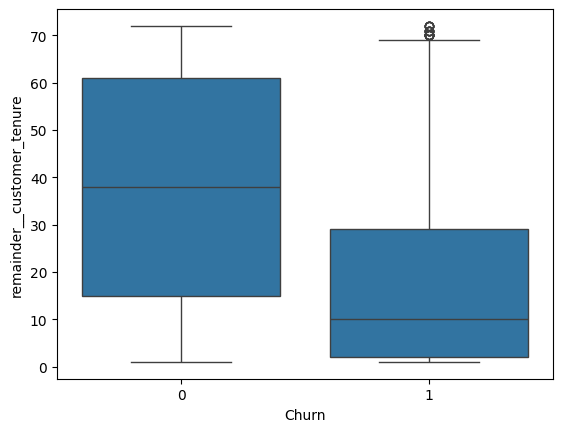

In [33]:
sns.boxplot(data=df_final, x='Churn', y='remainder__customer_tenure')

<Axes: xlabel='Churn', ylabel='remainder__account_charges_total'>

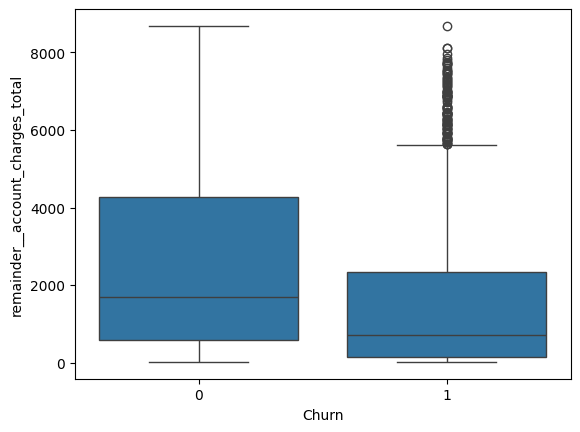

In [34]:
sns.boxplot(data=df_final, x='Churn', y='remainder__account_charges_total')

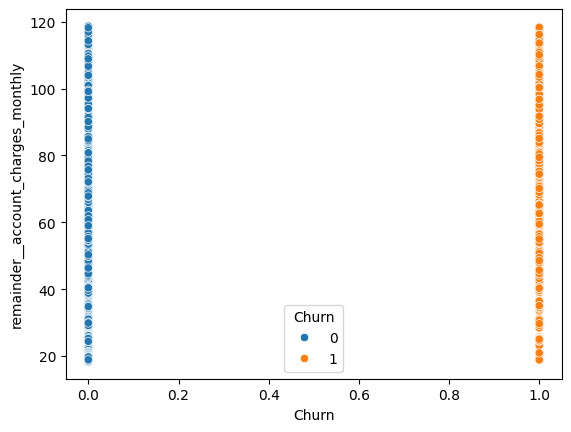

In [35]:
sns.scatterplot(data = df_final, x='Churn', y='remainder__account_charges_monthly', hue='Churn');

Separación de los Datos

In [36]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X_DF, y, test_size=0.3, stratify = y, random_state=30)

## Creación de modelos

In [64]:
pd.DataFrame(y_train).value_counts(normalize=True)

,proportion
0,
0,0.734254
1,0.265746


In [65]:
pd.DataFrame(y_test).value_counts(normalize=True)

,proportion
0,
0,0.734123
1,0.265877


## Primer modelo: Baseline o Dummy

In [66]:
from sklearn.dummy import DummyClassifier

In [67]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [68]:
y_predicho = dummy.predict(X_test)

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [70]:
matriz_confusion_dummy = confusion_matrix(y_test, y_predicho)
print(matriz_confusion_dummy)

[[1549    0]
 [ 561    0]]


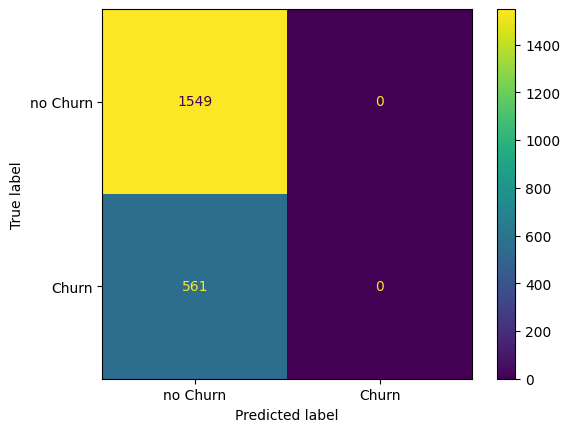

In [71]:
visualizacion_dummy = ConfusionMatrixDisplay(
    confusion_matrix = matriz_confusion_dummy,
    display_labels = ['no Churn' , 'Churn']
)
visualizacion_dummy.plot()

In [72]:
print(classification_report(y_test, y_predicho))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1549
           1       0.00      0.00      0.00       561

    accuracy                           0.73      2110
   macro avg       0.37      0.50      0.42      2110
weighted avg       0.54      0.73      0.62      2110



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Segundo modelo: Regresión logística

Debemos escalar algunos de los atributos para que funcione mejor este modelo

In [74]:
X_train_scaled = X_train.copy()

In [75]:
X_test_scaled = X_test.copy()

In [76]:
columnas_continuas = [
    'remainder__customer_tenure',
    'remainder__account_charges_monthly',
    'remainder__account_charges_total'
]

In [77]:
from sklearn.preprocessing import StandardScaler

In [79]:
scaler = StandardScaler()

In [80]:
scaler.fit(X_train_scaled[columnas_continuas])

StandardScaler()

In [81]:
X_train_scaled[columnas_continuas] = scaler.transform(X_train_scaled[columnas_continuas])

In [82]:
X_test_scaled[columnas_continuas] = scaler.transform(X_test_scaled[columnas_continuas])